# Diabetes dataset - EDA and Preprocessing Pipelines
# Hugo Manzano - 36231
## Introduction

In this notebook, we will perform exploratory data analysis (EDA) on the Pima indians diabatetes dataset, followed by building preprocessing pipelines for numerical and categorical features.

The dataset contains information about diabetes, their characteristics and metrics. The objective is to predict wheter a pacient will or not have diabetes, making this a **_binary classification_** problem. The dataset is sourced from Kaggle: https://www.kaggle.com/code/mragpavank/pima-indians-diabetes-database/input

Let's start by importing the necessary libraries and loading the dataset as a pandas DataFrame.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer

In [10]:
data = pd.read_csv('../INTCOMP/diabetes.csv')
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## Basic information and statistics

We can use the `.info()` method to get an overview of the dataset, including the number of non-null entries and data types for each column.

In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Similarly, we can use the `.describe()` method to get summary statistics for the numerical columns in the dataset. Note that in this example, we are transposing the output for better readability.

In [12]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In total we have 9 columns:

Pregnancies: Number of times pregnant.

Glucose: Plasma glucose concentration a 2 hours in an oral glucose tolerance test.

BloodPressure: Diastolic blood pressure (mm Hg).

SkinThickness: Triceps skin fold thickness (mm).

Insulin: 2-Hour serum insulin (mu U/ml).

BMI: Body mass index (weight in kg/(height in m)^2).

DiabetesPedigreeFunction: A function which scores likelihood of diabetes based on family history.

Age: Age of the patient (years).

Outcome: Class variable (0 = No diabetes, 1 = Diabetes).

In our analysis, we will keep all the columns since they are all numerical and represent medical indicators that are directly related to the probability of having diabetes. 

## Visualization of Numerical Features

Let's proceed with visualizing the distributions of the numerical features in the dataset. Note that even if the Outcome column is represented as an integer, it is categorical in nature (representing the presence or absence of diabetes) and will be skipped for this specific distribution analysis.

To visualize the distributions, we will use the seaborn library to create histograms with kernel density estimates (KDE) for each numerical column. This will help us identify the range of the data and detect anomalies, such as the high frequency of "0" values in variables like Insulin or BloodPressure.

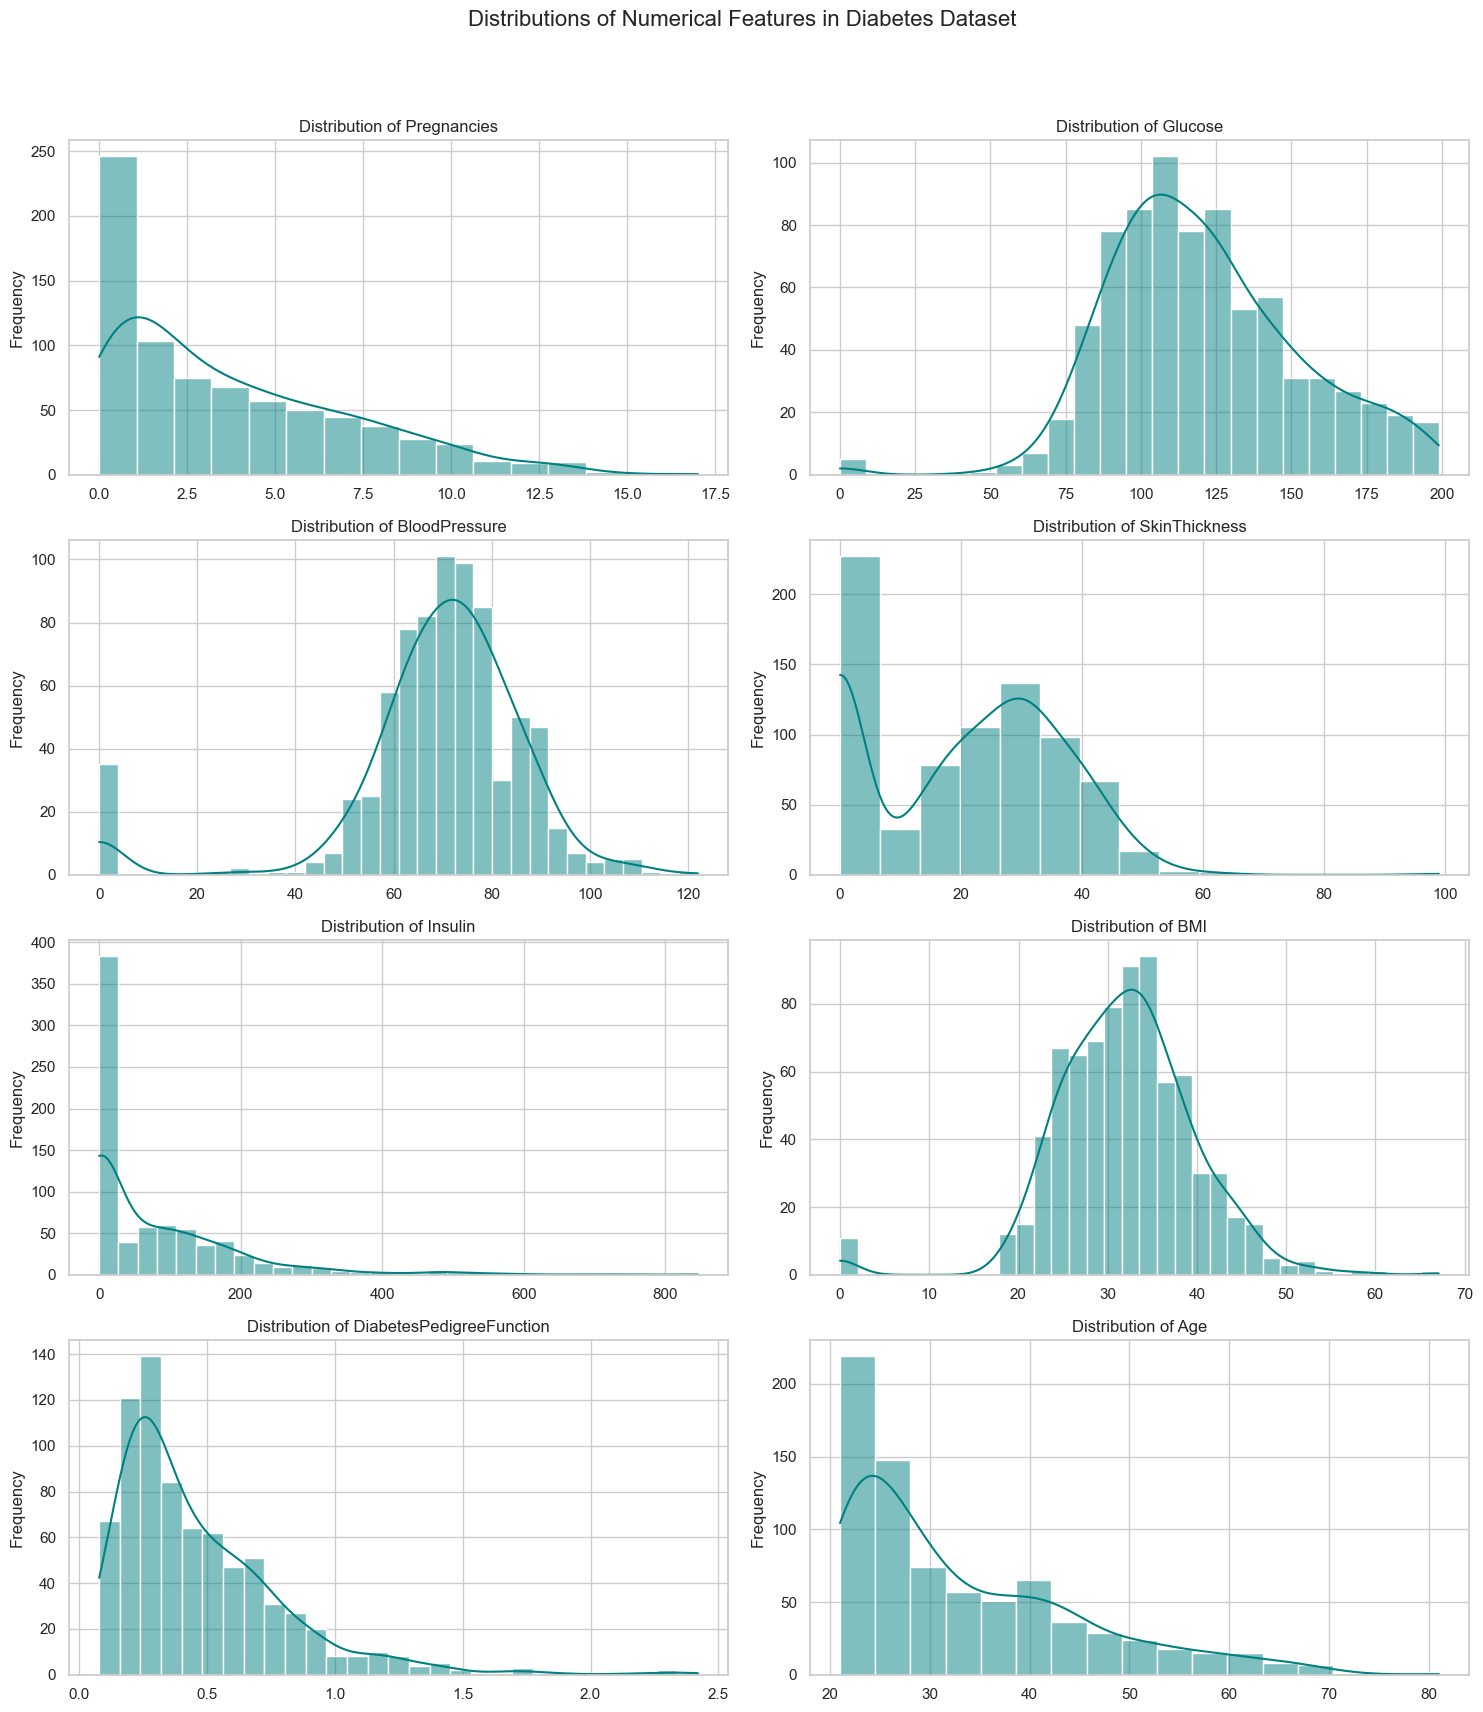

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos solo las columnas numéricas (excluyendo el objetivo 'Outcome')
numerical_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                  'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Configuramos el estilo de Seaborn
sns.set_theme(style="whitegrid")

# Creamos una cuadrícula de subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 18))
fig.suptitle('Distributions of Numerical Features in Diabetes Dataset', fontsize=16)

# Iteramos para crear los histogramas
for i, col in enumerate(numerical_cols):
    sns.histplot(data[col], kde=True, ax=axes[i//2, i%2], color='teal')
    axes[i//2, i%2].set_title(f'Distribution of {col}', fontsize=12)
    axes[i//2, i%2].set_xlabel('')
    axes[i//2, i%2].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Upon inspecting the distributions, we identified a critical data quality issue: several features such as Glucose, BloodPressure, SkinThickness, Insulin, and BMI contain a significant number of entries with a value of 0. Given that these are biological measurements, a value of zero is medically impossible for a living patient and clearly indicates missing data. Treating these zeros as real values would introduce severe bias into the model. Therefore, before training, these zero values must be handled appropriately, either by imputation (replacing them with the median or mean) or by removal, to ensure the model learns from realistic physiological patterns.

## Visualization of Categorical Features

This dataset primarily consists of continuous numerical medical measurements. However, it is crucial to analyze the distribution of our target variable, Outcome, to check for class imbalance. A significant imbalance between healthy and diabetic patients could bias the model's predictions.

Additionally, we will visualize Pregnancies as a discrete categorical feature, as the number of pregnancies is a count variable with a limited range of integer values.

/var/folders/gy/tj29j5z564gctfm2kmv59g_40000gn/T/ipykernel_15160/2118148875.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=data, palette='pastel', ax=axes[0])
/var/folders/gy/tj29j5z564gctfm2kmv59g_40000gn/T/ipykernel_15160/2118148875.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pregnancies', data=data, palette='viridis', ax=axes[1])


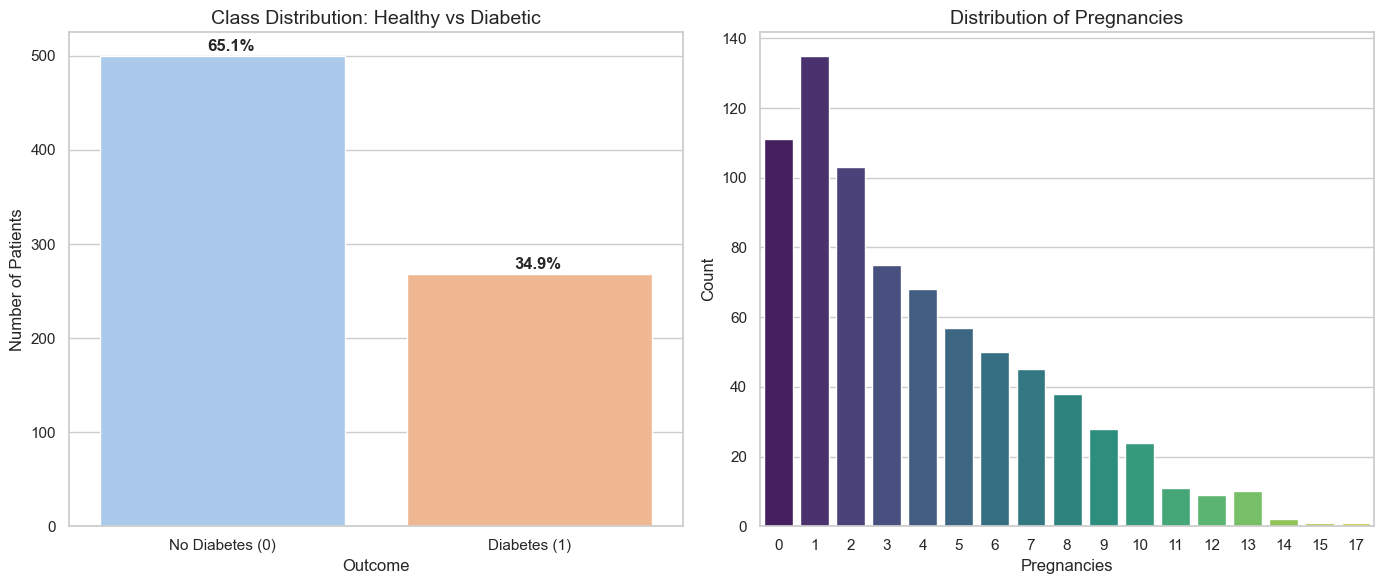

In [18]:
# Configurar el tamaño de la figura para dos gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Distribución del Objetivo (Outcome)
sns.countplot(x='Outcome', data=data, palette='pastel', ax=axes[0])
axes[0].set_title('Class Distribution: Healthy vs Diabetic', fontsize=14)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'])
axes[0].set_ylabel('Number of Patients')

# Añadir porcentajes encima de las barras
total = len(data)
for p in axes[0].patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 5
    axes[0].annotate(percentage, (x, y), size=12, weight='bold')

# Gráfico 2: Distribución de Embarazos (Discrete Feature)
sns.countplot(x='Pregnancies', data=data, palette='viridis', ax=axes[1])
axes[1].set_title('Distribution of Pregnancies', fontsize=14)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

The output confirms that there are no longer any missing values in the dataset. By replacing the invalid zeros with the median, we have ensured that the model will learn from representative physiological data rather than being biased by missing information. The dataset is now complete and ready for the next stages of preprocessing.

## Target label distribution

After examining the class distribution, we investigate how the numerical features differ between the two classes (Healthy vs. Diabetic).

We will use Boxplots to visualize the statistical summary (median, quartiles, and outliers) of key features for each Outcome. This allows us to observe if there is a clear separation between the distributions of positive and negative cases.

We can also compare the survival counts between the rest of the features. For example, with numerical features, we can create boxplots to visualize the distribution of numerical features for survivors and non-survivors.

/var/folders/gy/tj29j5z564gctfm2kmv59g_40000gn/T/ipykernel_15160/697849160.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=data, palette='Set2', ax=axes[i//2, i%2])
/var/folders/gy/tj29j5z564gctfm2kmv59g_40000gn/T/ipykernel_15160/697849160.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=data, palette='Set2', ax=axes[i//2, i%2])
/var/folders/gy/tj29j5z564gctfm2kmv59g_40000gn/T/ipykernel_15160/697849160.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=data

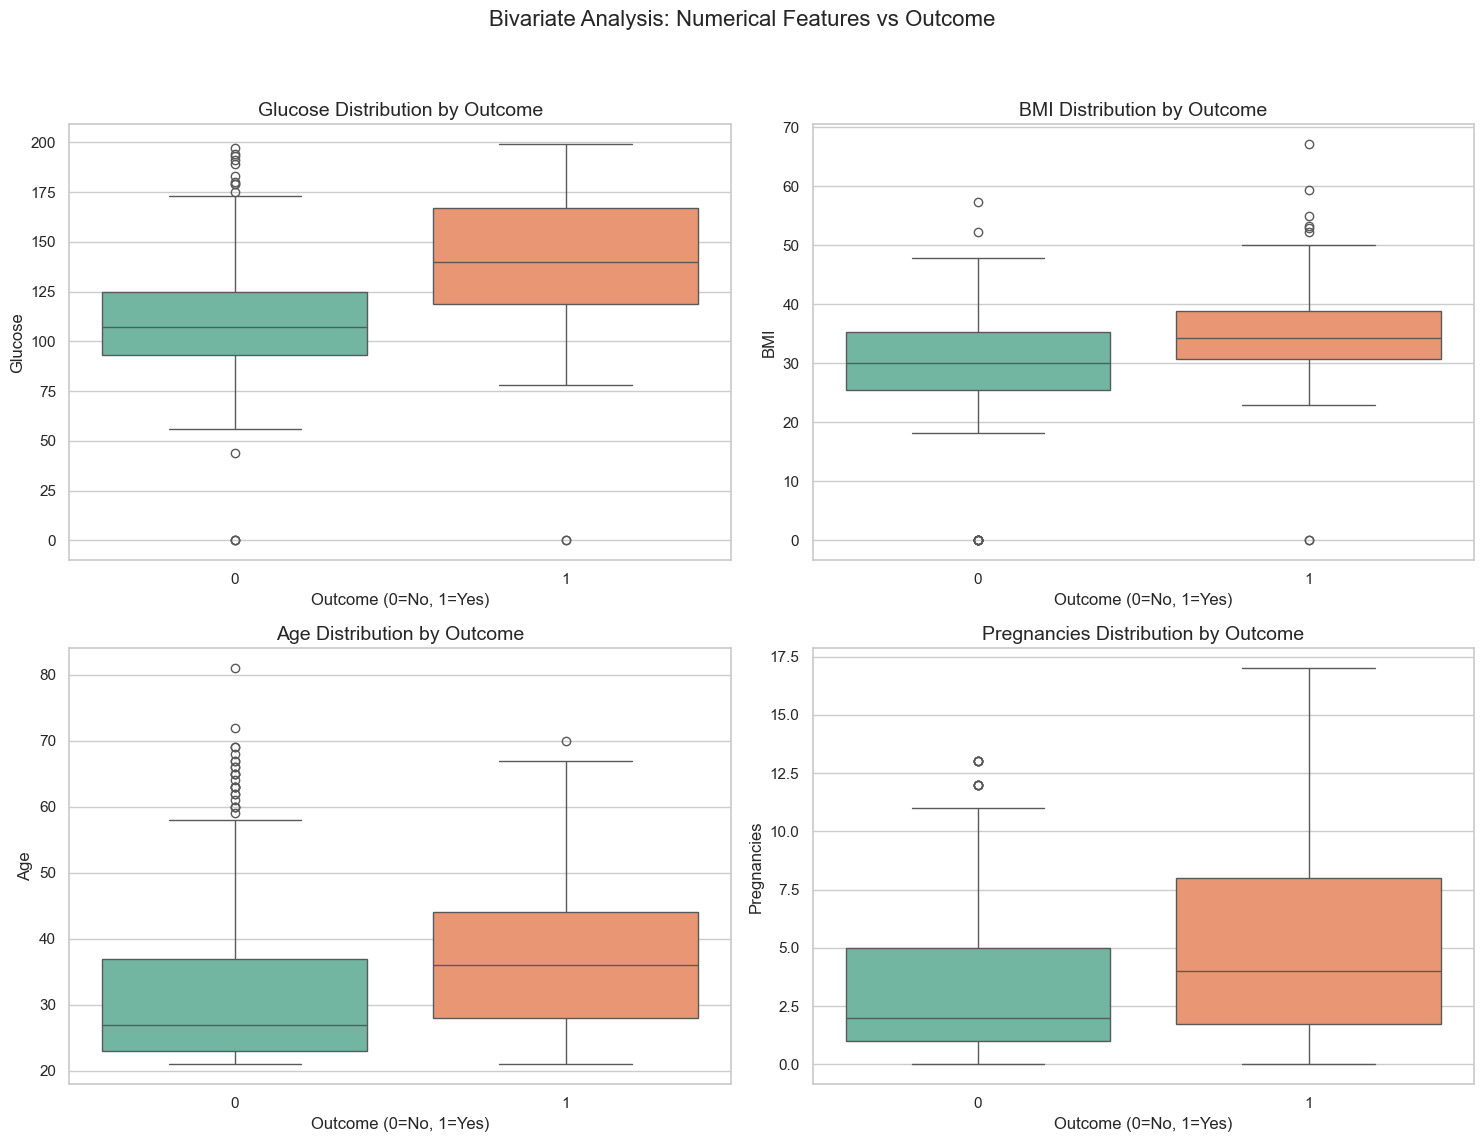

In [20]:
# Configurar la figura
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Bivariate Analysis: Numerical Features vs Outcome', fontsize=16)

# Lista de características clave para comparar
features_to_plot = ['Glucose', 'BMI', 'Age', 'Pregnancies']

for i, col in enumerate(features_to_plot):
    # Crear Boxplot: x=Outcome (Categoría), y=Variable Numérica
    sns.boxplot(x='Outcome', y=col, data=data, palette='Set2', ax=axes[i//2, i%2])
    
    # Títulos y etiquetas
    axes[i//2, i%2].set_title(f'{col} Distribution by Outcome', fontsize=14)
    axes[i//2, i%2].set_xlabel('Outcome (0=No, 1=Yes)')
    axes[i//2, i%2].set_ylabel(col)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The boxplots reveal significant distinct patterns between healthy and diabetic patients. Most notably, Glucose exhibits the clearest separation, where the median level for diabetic patients is substantially higher than for non-diabetic ones, confirming its status as a strong predictor. Similarly, Age and BMI show higher medians for the diabetic class, indicating that older individuals and those with a higher body mass index are at greater risk. While outliers are present in features like BMI (indicated by the points beyond the whiskers), the shift in distribution for these key variables suggests they hold high predictive value for our model.

We can also use a correlation matrix heatmap to visualize the correlations between all numerical columns (including `Pclass` and `Survived`).

This provides a mathematical measure to quantify the relationships observed in the previous visualizations.

Note that `Sex` and `Embarked` are not included in the correlation matrix since they are categorical features represented as strings. In the following section, we will apply one-hot encoding to these columns for preprocessing.

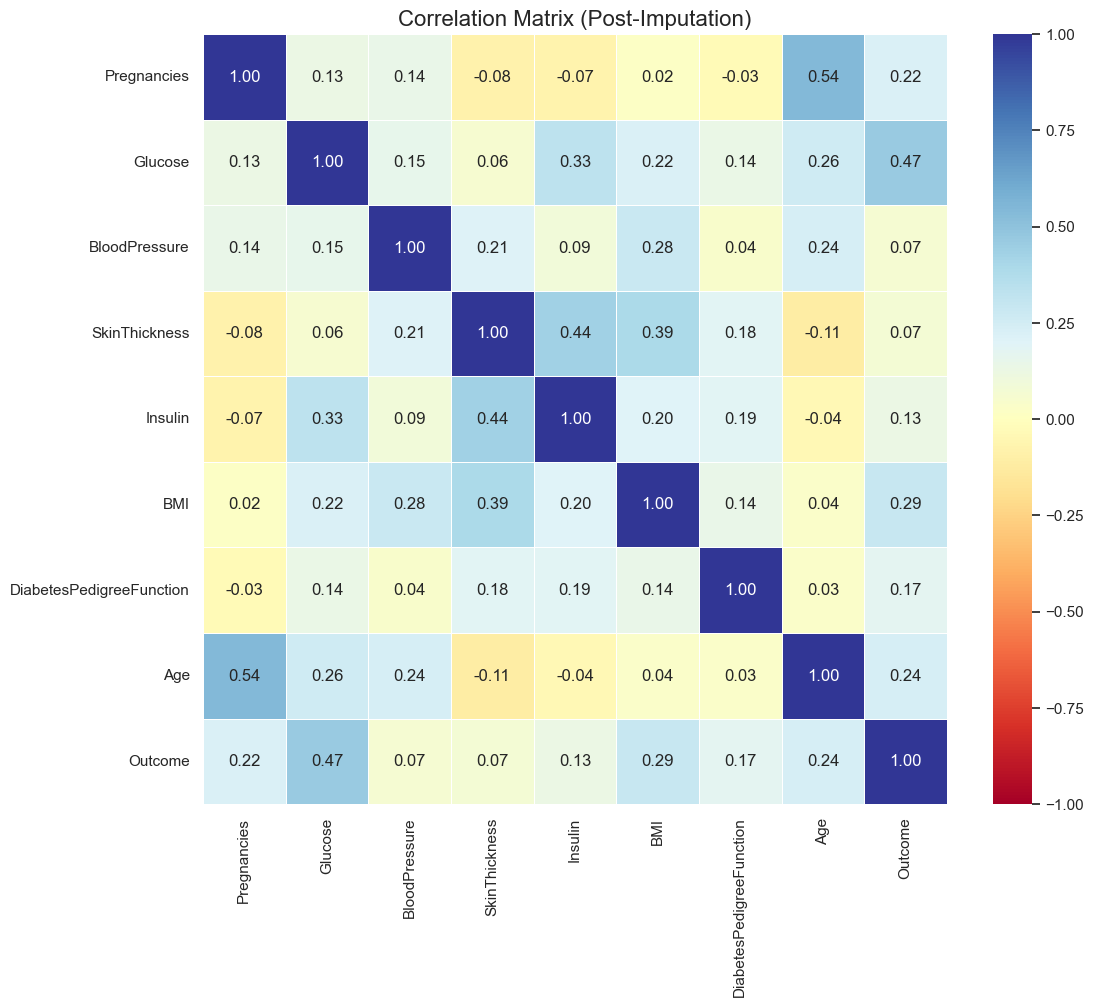

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la correlación sobre los datos LIMPIOS
corr_matrix = data.corr()

# Configurar el tamaño del gráfico
plt.figure(figsize=(12, 10))

# Generar el mapa de calor
sns.heatmap(corr_matrix, 
            annot=True,        # Escribe el valor dentro del cuadro
            fmt=".2f",         # Usa 2 decimales
            cmap='RdYlBu',     # Esquema de color: Rojo (negativo) a Azul (positivo)
            vmin=-1, vmax=1,   # Fija la escala entre -1 y 1
            linewidths=0.5)

plt.title('Correlation Matrix (Post-Imputation)', fontsize=16)
plt.show()

## Handling Missing Values

Before building preprocessing pipelines, it is important to analyze the missing values in the dataset. We can visualize the count of missing values for each column using a bar plot.

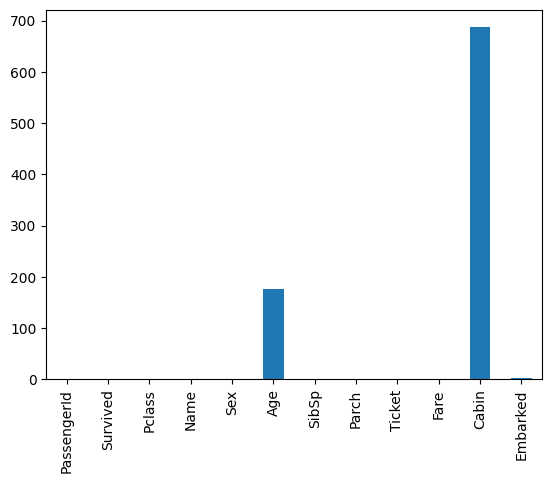

In [11]:
missing_counts = data.isnull().sum()
missing_counts.plot(kind='bar')

We can also calculate the percentage of missing values for each column to get a better understanding of the extent of missing data.

In [12]:
missing_percent = data.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

With the prior in mind, we need to choose appropriate strategies for handling missing values in our preprocessing pipelines. For numerical features, we can use the mean imputation strategy, while for categorical features, we can use the most frequent value imputation strategy.

More specifically, we will use the following strategies:
- **Cabin**: Drop the column entirely due to high cardinality and many missing values
- **Age**: Impute missing values with the mean of the column
- **Embarked**: Impute missing values with the most frequent value in the column



## Preprocessing pipelines

Now that we have analyzed the dataset and manually handled the invalid zero values, we can proceed to build preprocessing pipelines to standardize the data for the model.

We can declaratively create a preprocessing pipeline using ColumnTransformer. Since our dataset is purely numerical, we do not need categorical encodings like One-Hot Encoding. However, scaling is critical. The transformations we will apply are:

To all numerical columns (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age):

Impute missing values: We will add a SimpleImputer with the median strategy. Even though we already cleaned the data manually, including this step in the pipeline ensures that any future data (like the Test set) is automatically handled correctly.

Standard Scaling: We will apply StandardScaler to normalize the features (mean=0, variance=1), ensuring that variables with larger ranges (like Insulin) do not dominate the model over smaller ones (like DiabetesPedigreeFunction).

In [23]:
from sklearn.model_selection import train_test_split

# 1. Separar el Objetivo (y) de las Variables (X)
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# 2. Dividir en Entrenamiento (80%) y Prueba (20%)
# Es crucial hacer esto ANTES del pipeline
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data successfully split. X shape: {X.shape}")

Data successfully split. X shape: (768, 8)


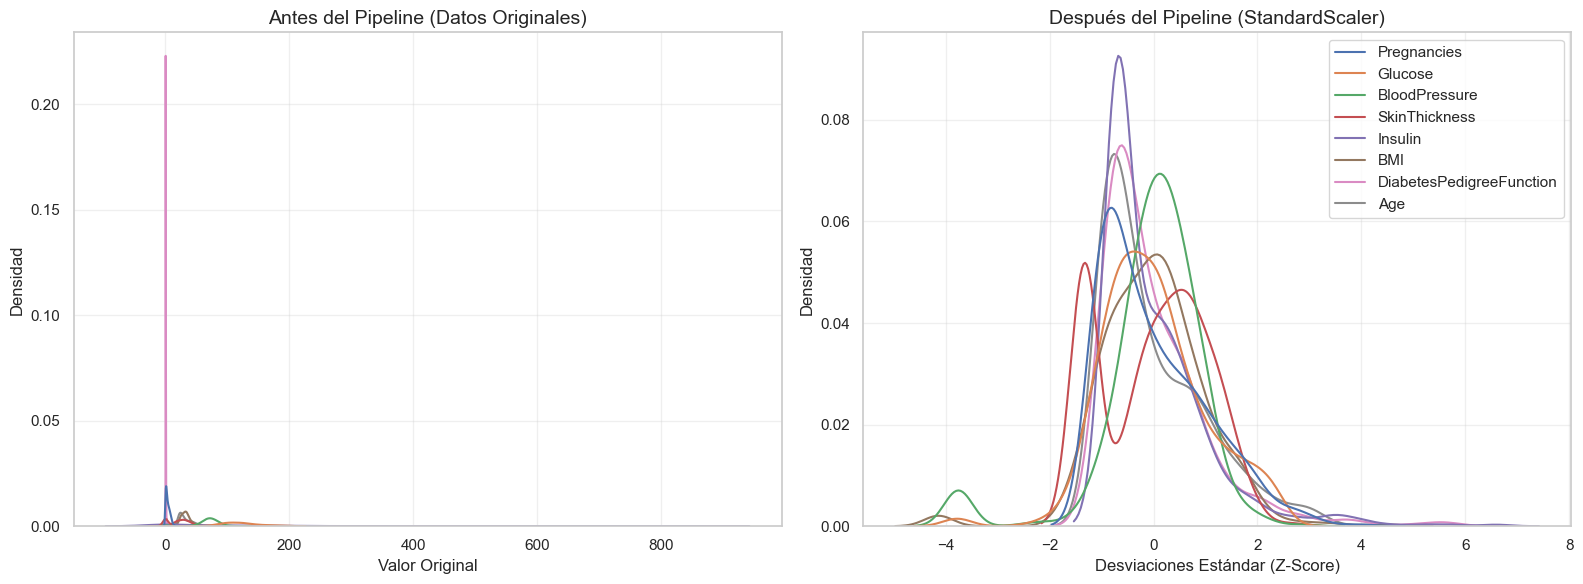

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn import set_config

# 1. Definir las columnas numéricas
numerical_cols = X.columns.tolist()

# 2. Crear el "Transformer" Numérico
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Rellena ceros/nulos
    ('scaler', StandardScaler())                    # Escala los datos
])

# 3. Crear el Preprocessor (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols)
    ])

# --- VISUALIZACIÓN DEL EFECTO DEL PIPELINE ---

# 1. Primero "entrenamos" el pipeline y transformamos los datos
# Esto ejecuta el Imputer (rellena huecos) y el Scaler (normaliza)
X_train_scaled = preprocessor.fit_transform(X_train)

# 2. Convertimos el resultado (que es un array de Numpy) a DataFrame
# Hacemos esto para que las gráficas tengan los nombres de las columnas
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=numerical_cols)

# 3. Graficar las distribuciones ANTES y DESPUÉS
# Creamos una figura con dos paneles para comparar
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16, 6))

# Gráfica A: Datos Originales (con rangos muy distintos)
sns.kdeplot(data=X_train, ax=ax1, legend=False) 
ax1.set_title('Antes del Pipeline (Datos Originales)', fontsize=14)
ax1.set_xlabel('Valor Original')
ax1.set_ylabel('Densidad')
ax1.grid(True, alpha=0.3)

# Gráfica B: Datos Procesados (Todos centrados en 0)
sns.kdeplot(data=X_train_scaled_df, ax=ax2, legend=True)
ax2.set_title('Después del Pipeline (StandardScaler)', fontsize=14)
ax2.set_xlabel('Desviaciones Estándar (Z-Score)')
ax2.set_ylabel('Densidad')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show() # Importante en VS Code para que abra la ventana

The visualization above confirms the effectiveness of the preprocessing pipeline.

Left Plot (Original): Features have vastly different scales (e.g., Insulin vs. Pedigree Function), which would confuse the Logistic Regression model.

Right Plot (Scaled): After passing through the StandardScaler, all features are normalized (centered at 0 with unit variance). This ensures that every variable contributes equally to the model's decision-making process.

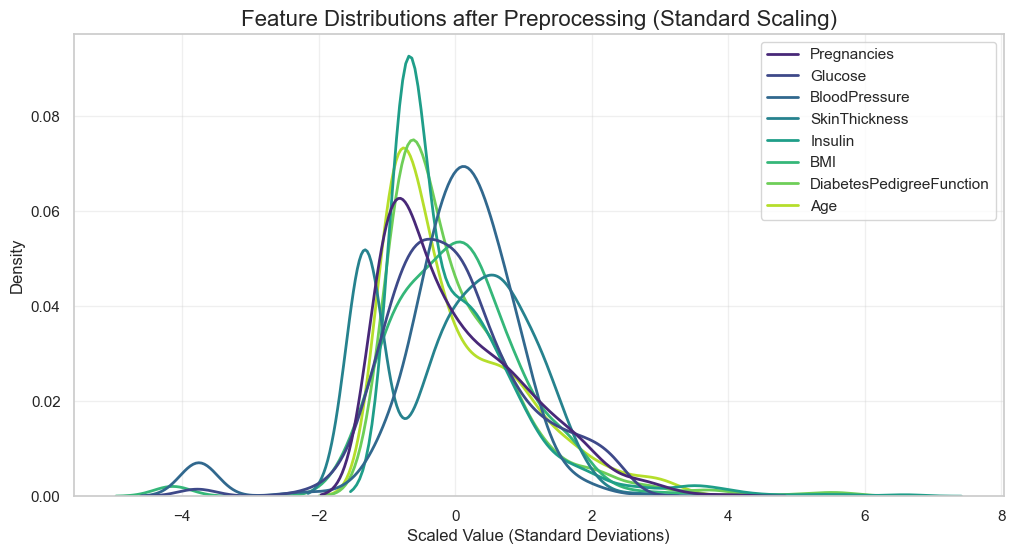

In [29]:
# 1. Aplicar el pipeline a los datos de entrenamiento
# Esto "entrena" el imputer/scaler y transforma los datos en un solo paso
X_train_processed = preprocessor.fit_transform(X_train)

# 2. Convertir el resultado (que es una matriz de números) a DataFrame
# Hacemos esto para poder usar los nombres de las columnas en la gráfica
X_train_processed_df = pd.DataFrame(X_train_processed, columns=numerical_cols)

# 3. Visualizar las distribuciones escaladas
plt.figure(figsize=(12, 6))
sns.kdeplot(data=X_train_processed_df, linewidth=2, palette='viridis')

plt.title('Feature Distributions after Preprocessing (Standard Scaling)', fontsize=16)
plt.xlabel('Scaled Value (Standard Deviations)')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)
plt.show()

Analysis of Scaled Distributions

The plot above demonstrates the effect of the StandardScaler. All numerical features have been transformed to have a mean of approximately 0 and a standard deviation of 1.

Unlike the original raw data, where Insulin (ranging up to 800) and DiabetesPedigreeFunction (ranging 0-2) were incomparable, now all features share the same scale. This is crucial for the Logistic Regression algorithm to function correctly, as it treats all features with equal importance during the optimization process.

## Building a Classification Model

Now that the data preprocessing pipeline is established, we can define the final model. For this binary classification problem, we will use Logistic Regression.

We will create a full pipeline that combines the preprocessing steps (Imputation + Scaling) with the Classifier. This ensures that the data is automatically processed before being fed into the model during training and future predictions.

In [35]:
from sklearn.linear_model import LogisticRegression

# 1. Definir el modelo
# Usamos LogisticRegression, que es ideal para resultados binarios (0 o 1)
# solver='liblinear' es recomendado para datasets pequeños como este
model = LogisticRegression(random_state=42, solver='liblinear')

# 2. Crear el Pipeline Completo (Preprocessing + Modelo)
# Esto une la limpieza con la predicción en un solo objeto
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

# 3. Entrenar el modelo (Fit)
# Aquí la IA aprende la relación entre X (Glucosa, Edad, etc.) e y (Diabetes)
clf.fit(X_train, y_train)

print("Model trained successfully!")

# 4. Verificar la precisión básica en el set de entrenamiento
print(f"Accuracy on Training set: {clf.score(X_train, y_train):.4f}")

Model trained successfully!
Accuracy on Training set: 0.7704


The `classification_model` object is now a complete pipeline that first preprocesses the input data and then applies logistic regression for classification. If we output the steps of the pipeline, we can see the individual components that make up the complete model.

In [39]:
clf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

Now that the pipeline is set up, we can fit the model to the training data using the `fit` method. This will internally call the `fit_transform` method of the preprocessing pipeline on the training data, followed by fitting the logistic regression model on the transformed data.

In [41]:
clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

With our trained model, we can now make predictions on the test set using the `predict` method. This will internally call the `transform` method of the preprocessing pipeline on the test data, followed by making predictions using the logistic regression model.

In [43]:
y_test_pred = clf.predict(X_test)
y_test_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

Finally, we can evaluate the model's performance by comparing the predicted labels with the actual labels from the test set. One simple way to do this is by creating a DataFrame that shows both the predicted and actual labels side by side for each passenger in the test set.

In [44]:
X_test['Survived_Predicted'] = y_test_pred
X_test['Survived_Actual'] = y_test.values
X_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Survived_Predicted,Survived_Actual
668,6,98,58,33,190,34.0,0.430,43,0,0
324,2,112,75,32,0,35.7,0.148,21,0,0
624,2,108,64,0,0,30.8,0.158,21,0,0
690,8,107,80,0,0,24.6,0.856,34,0,0
473,7,136,90,0,0,29.9,0.210,50,0,0
...,...,...,...,...,...,...,...,...,...,...
355,9,165,88,0,0,30.4,0.302,49,1,1
534,1,77,56,30,56,33.3,1.251,24,0,0
344,8,95,72,0,0,36.8,0.485,57,0,0
296,2,146,70,38,360,28.0,0.337,29,0,1
